# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [41]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [42]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


Hidden, underlying patterns in the real estate market can prevent accurate property valuation by Zillow, negatively affecting the platform's users and ultimately the company's business goals. The objective of this project is to improve Zillow's valuation feature, which will enable real estate professionals and prospective homebuyers to make more informed decisions regarding the sale of properties. The project will use key property features to predict property tax values, highlighting how certain characteristics contribute to this assessment. Due to increased trust in its capabilities, Zillow will see expanded usage by drivers of the real estate market and be able to grow its credibility and influence in the industry.

**1.2:**  How will your solution be used?


**1.3:**  How should success (or failure) be measured?


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [43]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

display(df.head())

df.info()

feature_overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "nunique": df.nunique(),
    }
)
feature_overview["usefulness_note"] = np.where(
    feature_overview.index == "taxvaluedollarcnt",
    "Regression target",
    "",
)
display(feature_overview.sort_values("missing_pct", ascending=False))

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,NaN,3100.0,3100.0,NaN,NaN,NaN,NaN,6059.0,NaN,3.0,2.0,633.0,NaN,NaN,33634931.0,-117869207.0,4506.0,NaN,NaN,NaN,NaN,NaN,122,261.0,NaN,6.059063e+07,53571.0,1286.0,NaN,96978.0,0.0,NaN,1.0,NaN,NaN,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,1465.0,1465.0,1465.0,NaN,NaN,1465.0,NaN,6111.0,1.0,1.0,1.0,0.0,NaN,NaN,34449266.0,-119281531.0,12647.0,NaN,NaN,NaN,NaN,NaN,1110,261.0,NaN,6.111001e+07,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,NaN,1243.0,1243.0,NaN,NaN,NaN,NaN,6059.0,NaN,2.0,2.0,440.0,NaN,NaN,33886168.0,-117823170.0,8432.0,1.0,NaN,NaN,NaN,1.0,122,261.0,NaN,6.059022e+07,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,NaN,2376.0,2376.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34245180.0,-118240722.0,13038.0,1.0,NaN,NaN,NaN,1.0,0101,261.0,LCR110000*,6.037300e+07,396551.0,3101.0,NaN,96330.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,NaN,1312.0,1312.0,NaN,NaN,NaN,NaN,6037.0,NaN,3.0,NaN,NaN,NaN,2.0,34185120.0,-118414640.0,278581.0,1.0,NaN,NaN,NaN,1.0,010C,266.0,LAR3,6.037124e+07,12447.0,3101.0,268548.0,96451.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

,dtype,missing_pct,nunique,usefulness_note
buildingclasstypeid,float64,99.98,2,
finishedsquarefeet13,float64,99.95,13,
basementsqft,float64,99.94,43,
storytypeid,float64,99.94,1,
yardbuildingsqft26,float64,99.91,59,
fireplaceflag,object,99.78,1,
architecturalstyletypeid,float64,99.73,5,
typeconstructiontypeid,float64,99.71,4,
finishedsquarefeet6,float64,99.50,350,
pooltypeid10,float64,99.40,1,


In [44]:
display(df["numberofstories"].head(20))

0     NaN
1     1.0
2     1.0
3     NaN
4     NaN
5     2.0
6     NaN
7     NaN
8     NaN
9     NaN
10    NaN
11    2.0
12    NaN
13    2.0
14    NaN
15    2.0
16    1.0
17    NaN
18    NaN
19    NaN
Name: numberofstories, dtype: float64

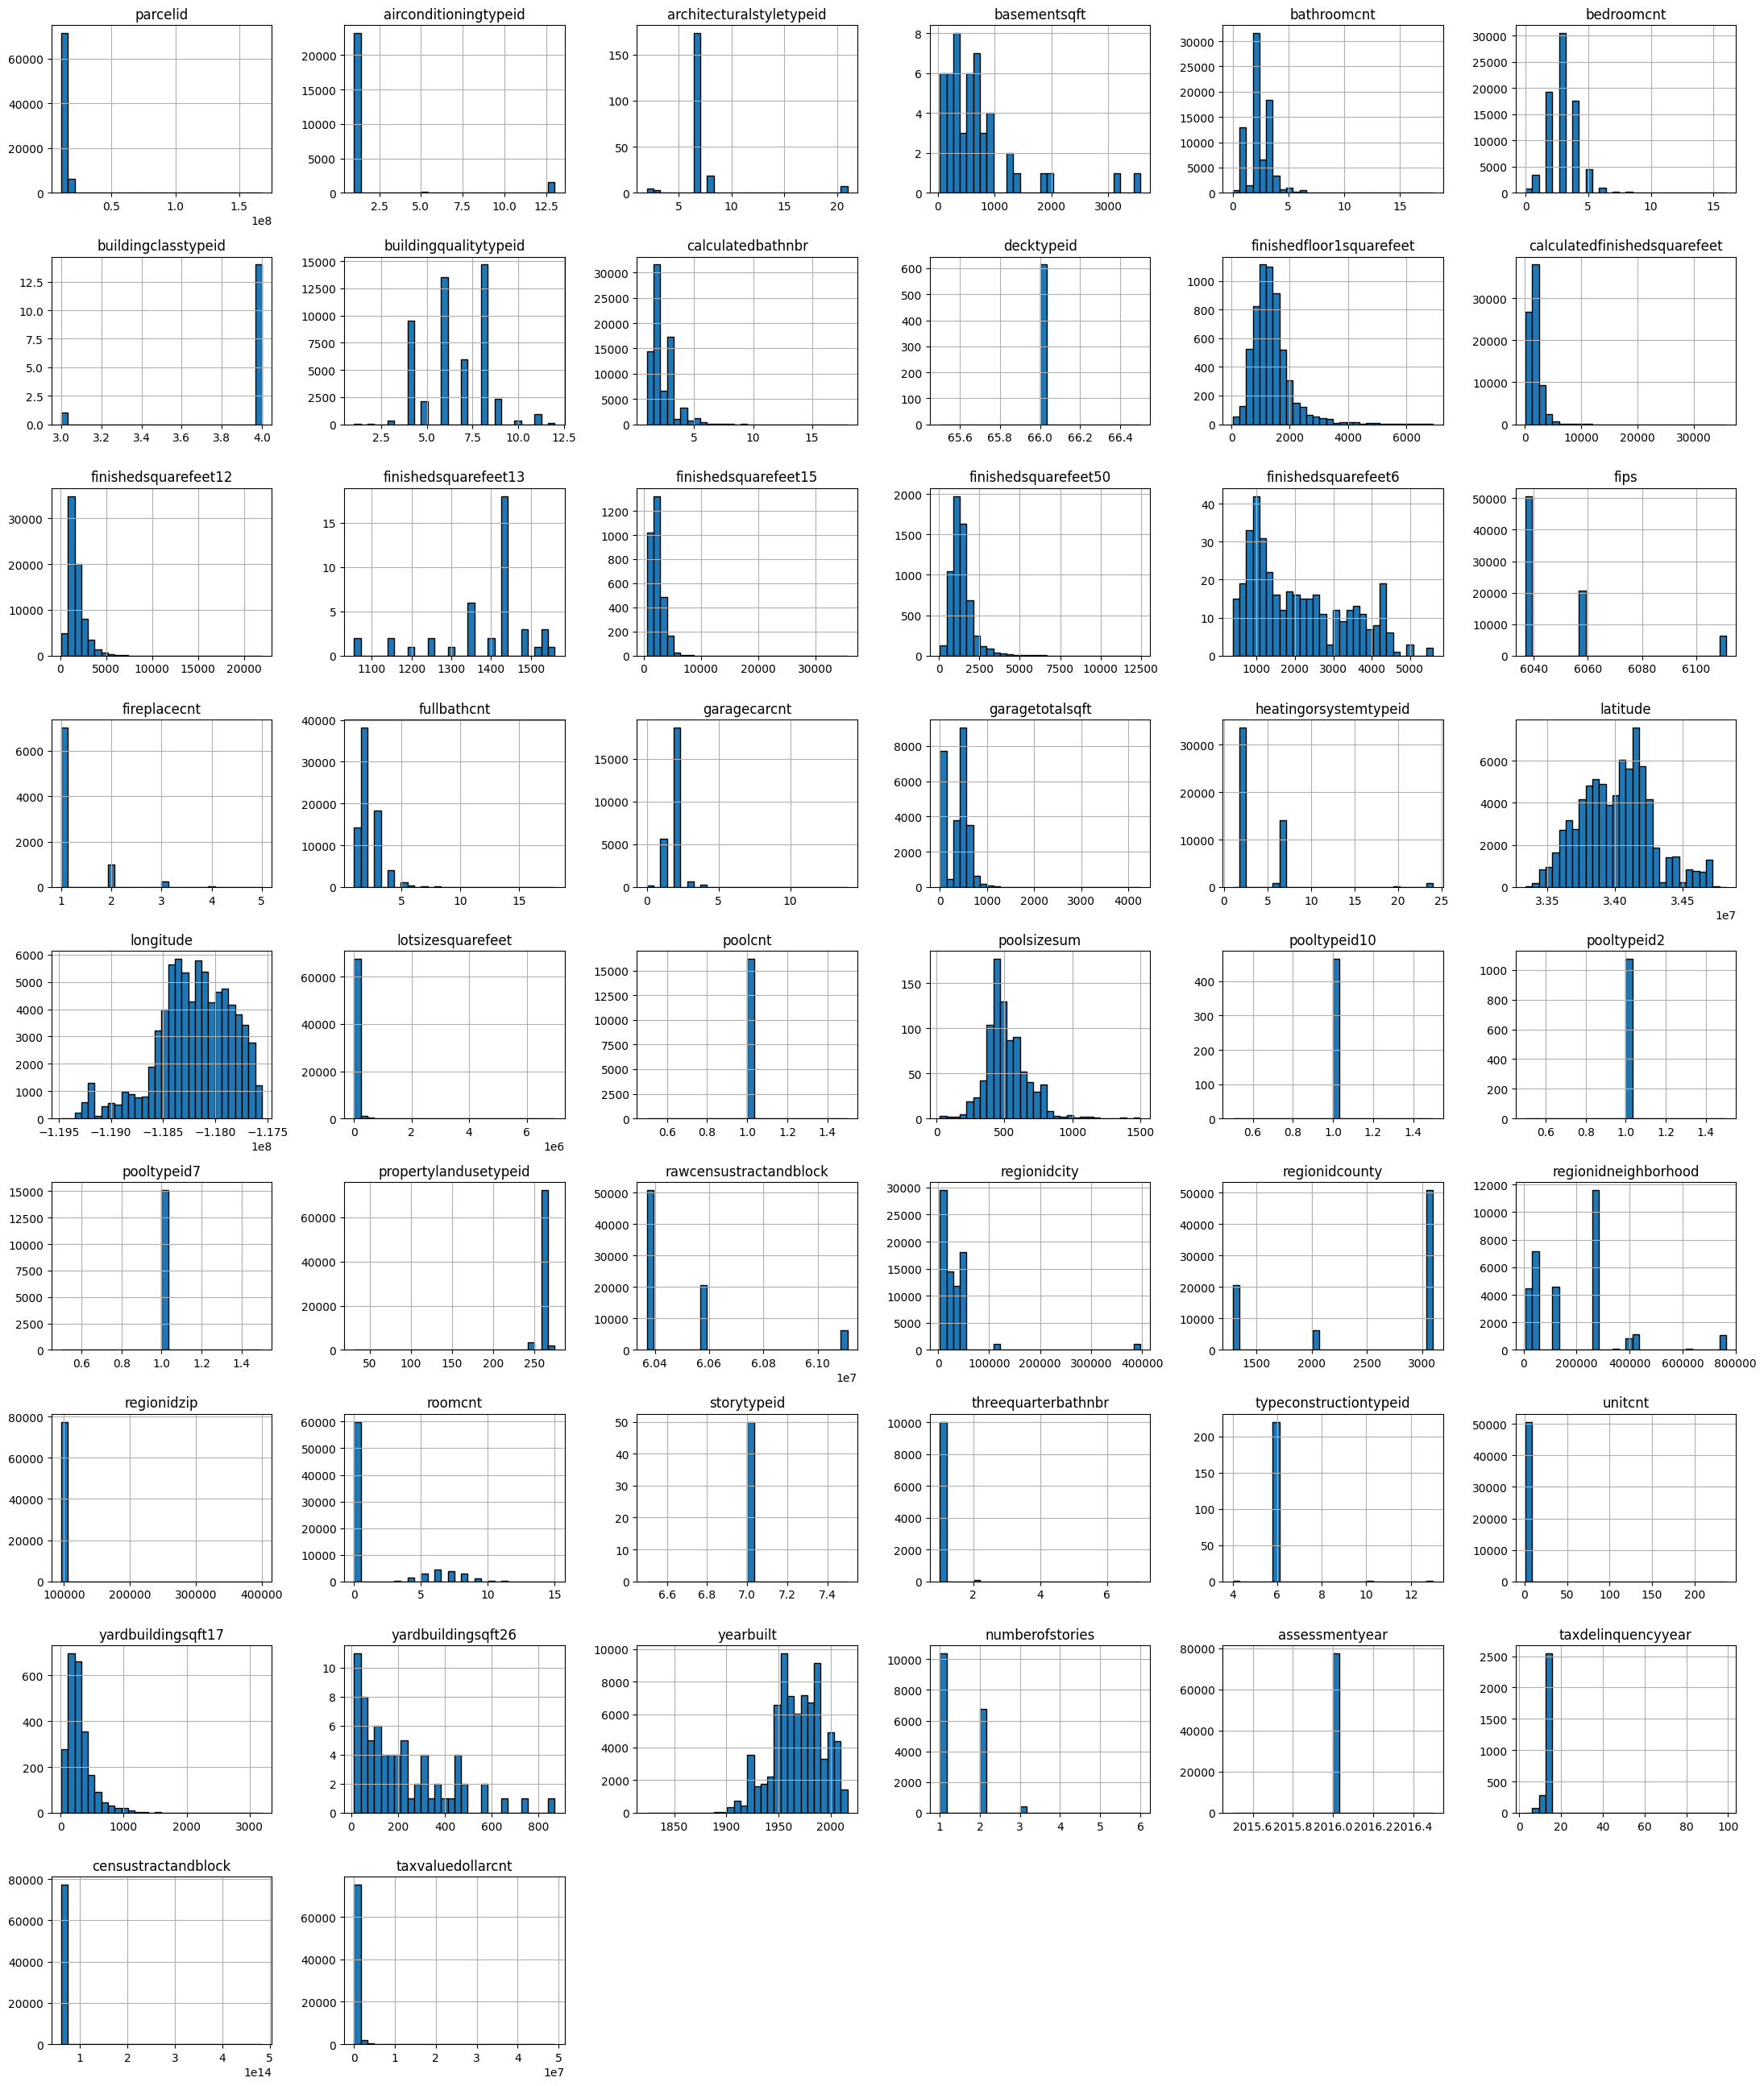

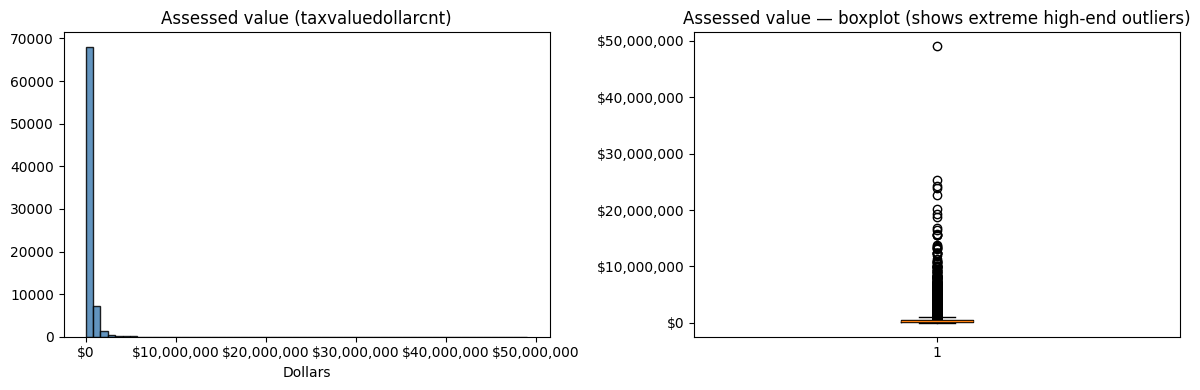

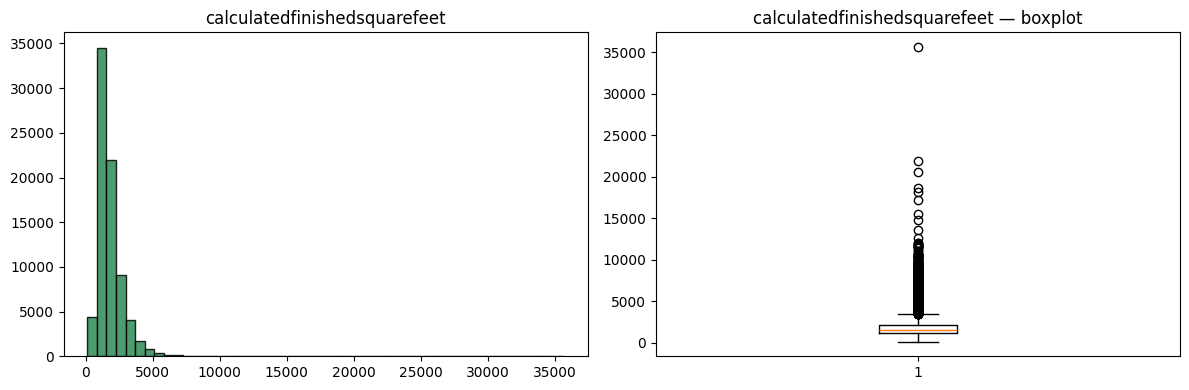

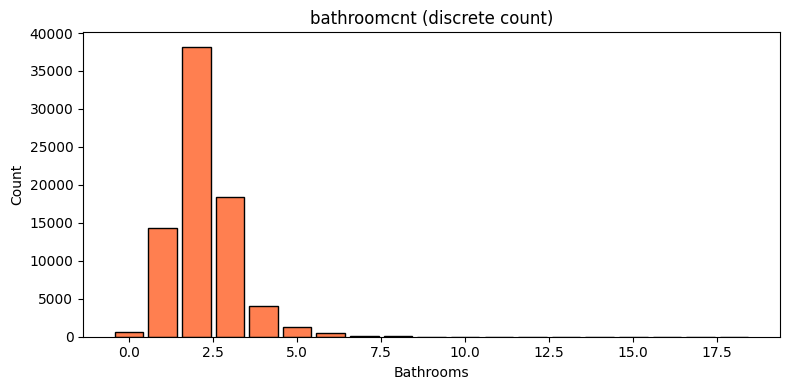

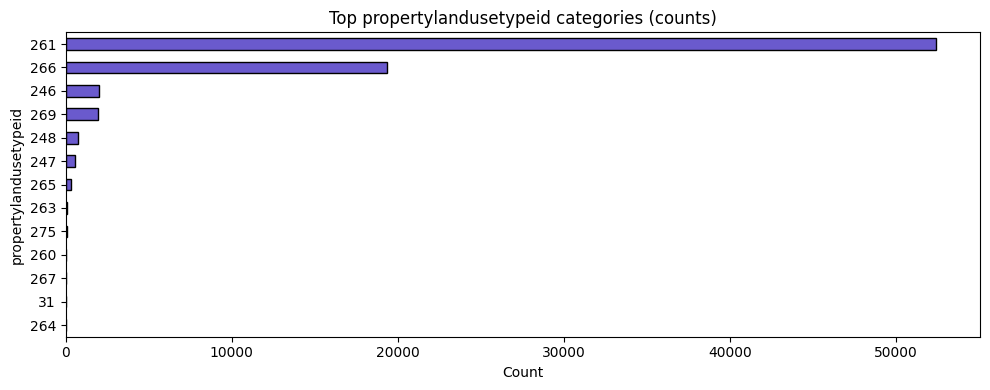

In [45]:
# --- All features: quick univariate overview ---
_ = df.hist(figsize=(22, 26), layout=(-1, 6), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

# --- Target: strongly right-skewed; very large upper tail (luxury / estates) ---
target = df["taxvaluedollarcnt"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target, bins=60, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].set_title("Assessed value (taxvaluedollarcnt)")
axes[0].set_xlabel("Dollars")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[1].boxplot(target, vert=True)
axes[1].set_title("Assessed value — boxplot (shows extreme high-end outliers)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.tight_layout()
plt.show()

# --- Feature 1 (numeric): finished living area — core size driver ---
sqft = df["calculatedfinishedsquarefeet"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sqft, bins=50, color="seagreen", edgecolor="black", alpha=0.85)
axes[0].set_title("calculatedfinishedsquarefeet")
axes[1].boxplot(sqft, vert=True)
axes[1].set_title("calculatedfinishedsquarefeet — boxplot")
plt.tight_layout()
plt.show()

# --- Feature 2 (numeric): bathrooms ---
bath = df["bathroomcnt"].dropna()
plt.figure(figsize=(8, 4))
plt.hist(bath, bins=range(0, int(bath.max()) + 2), align="left", rwidth=0.85, color="coral", edgecolor="black")
plt.title("bathroomcnt (discrete count)")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Feature 3 (categorical code): land use type — bar chart of counts ---
land_use = df["propertylandusetypeid"].dropna().astype(int)
vc = land_use.value_counts().head(15)
plt.figure(figsize=(10, 4))
vc.sort_values().plot(kind="barh", color="slateblue", edgecolor="black")
plt.title("Top propertylandusetypeid categories (counts)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Pandas loads five columns as object/string: hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, and taxdelinquencyflag - treat these as categorical/text. Many other numeric columns are actually categorical codes (e.g., fips, propertylandusetypeid, airconditioningtypeid, regionidcity/zip/county/neighborhood, and various typeid/flag fields). Handle them as nominal/ordinal, not continuous measures.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

parcelid: row identifier — risks leakage and won’t generalize. rawcensustractandblock: duplicates censustractandblock. assessmentyear: nearly constant here, so no discriminative value. These are good candidates to drop.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Many columns are ~99–100% missing (e.g., buildingclasstypeid, basementsqft, finishedsquarefeet13, storytypeid). Pool/deck fields (poolsizesum, pooltypeid2, decktypeid) are >98% missing. Drop these rather than impute — imputation would mostly invent data.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Columns with a single observed value (besides NaN) are uninformative (some pool/deck/story IDs, assessmentyear). Very high-cardinality fields (latitude, longitude, fine-grained census/geoid) are not useless but need special handling (binning, target encoding, or tree models) instead of one-hot encoding. The target is naturally high-cardinality because it’s continuous.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

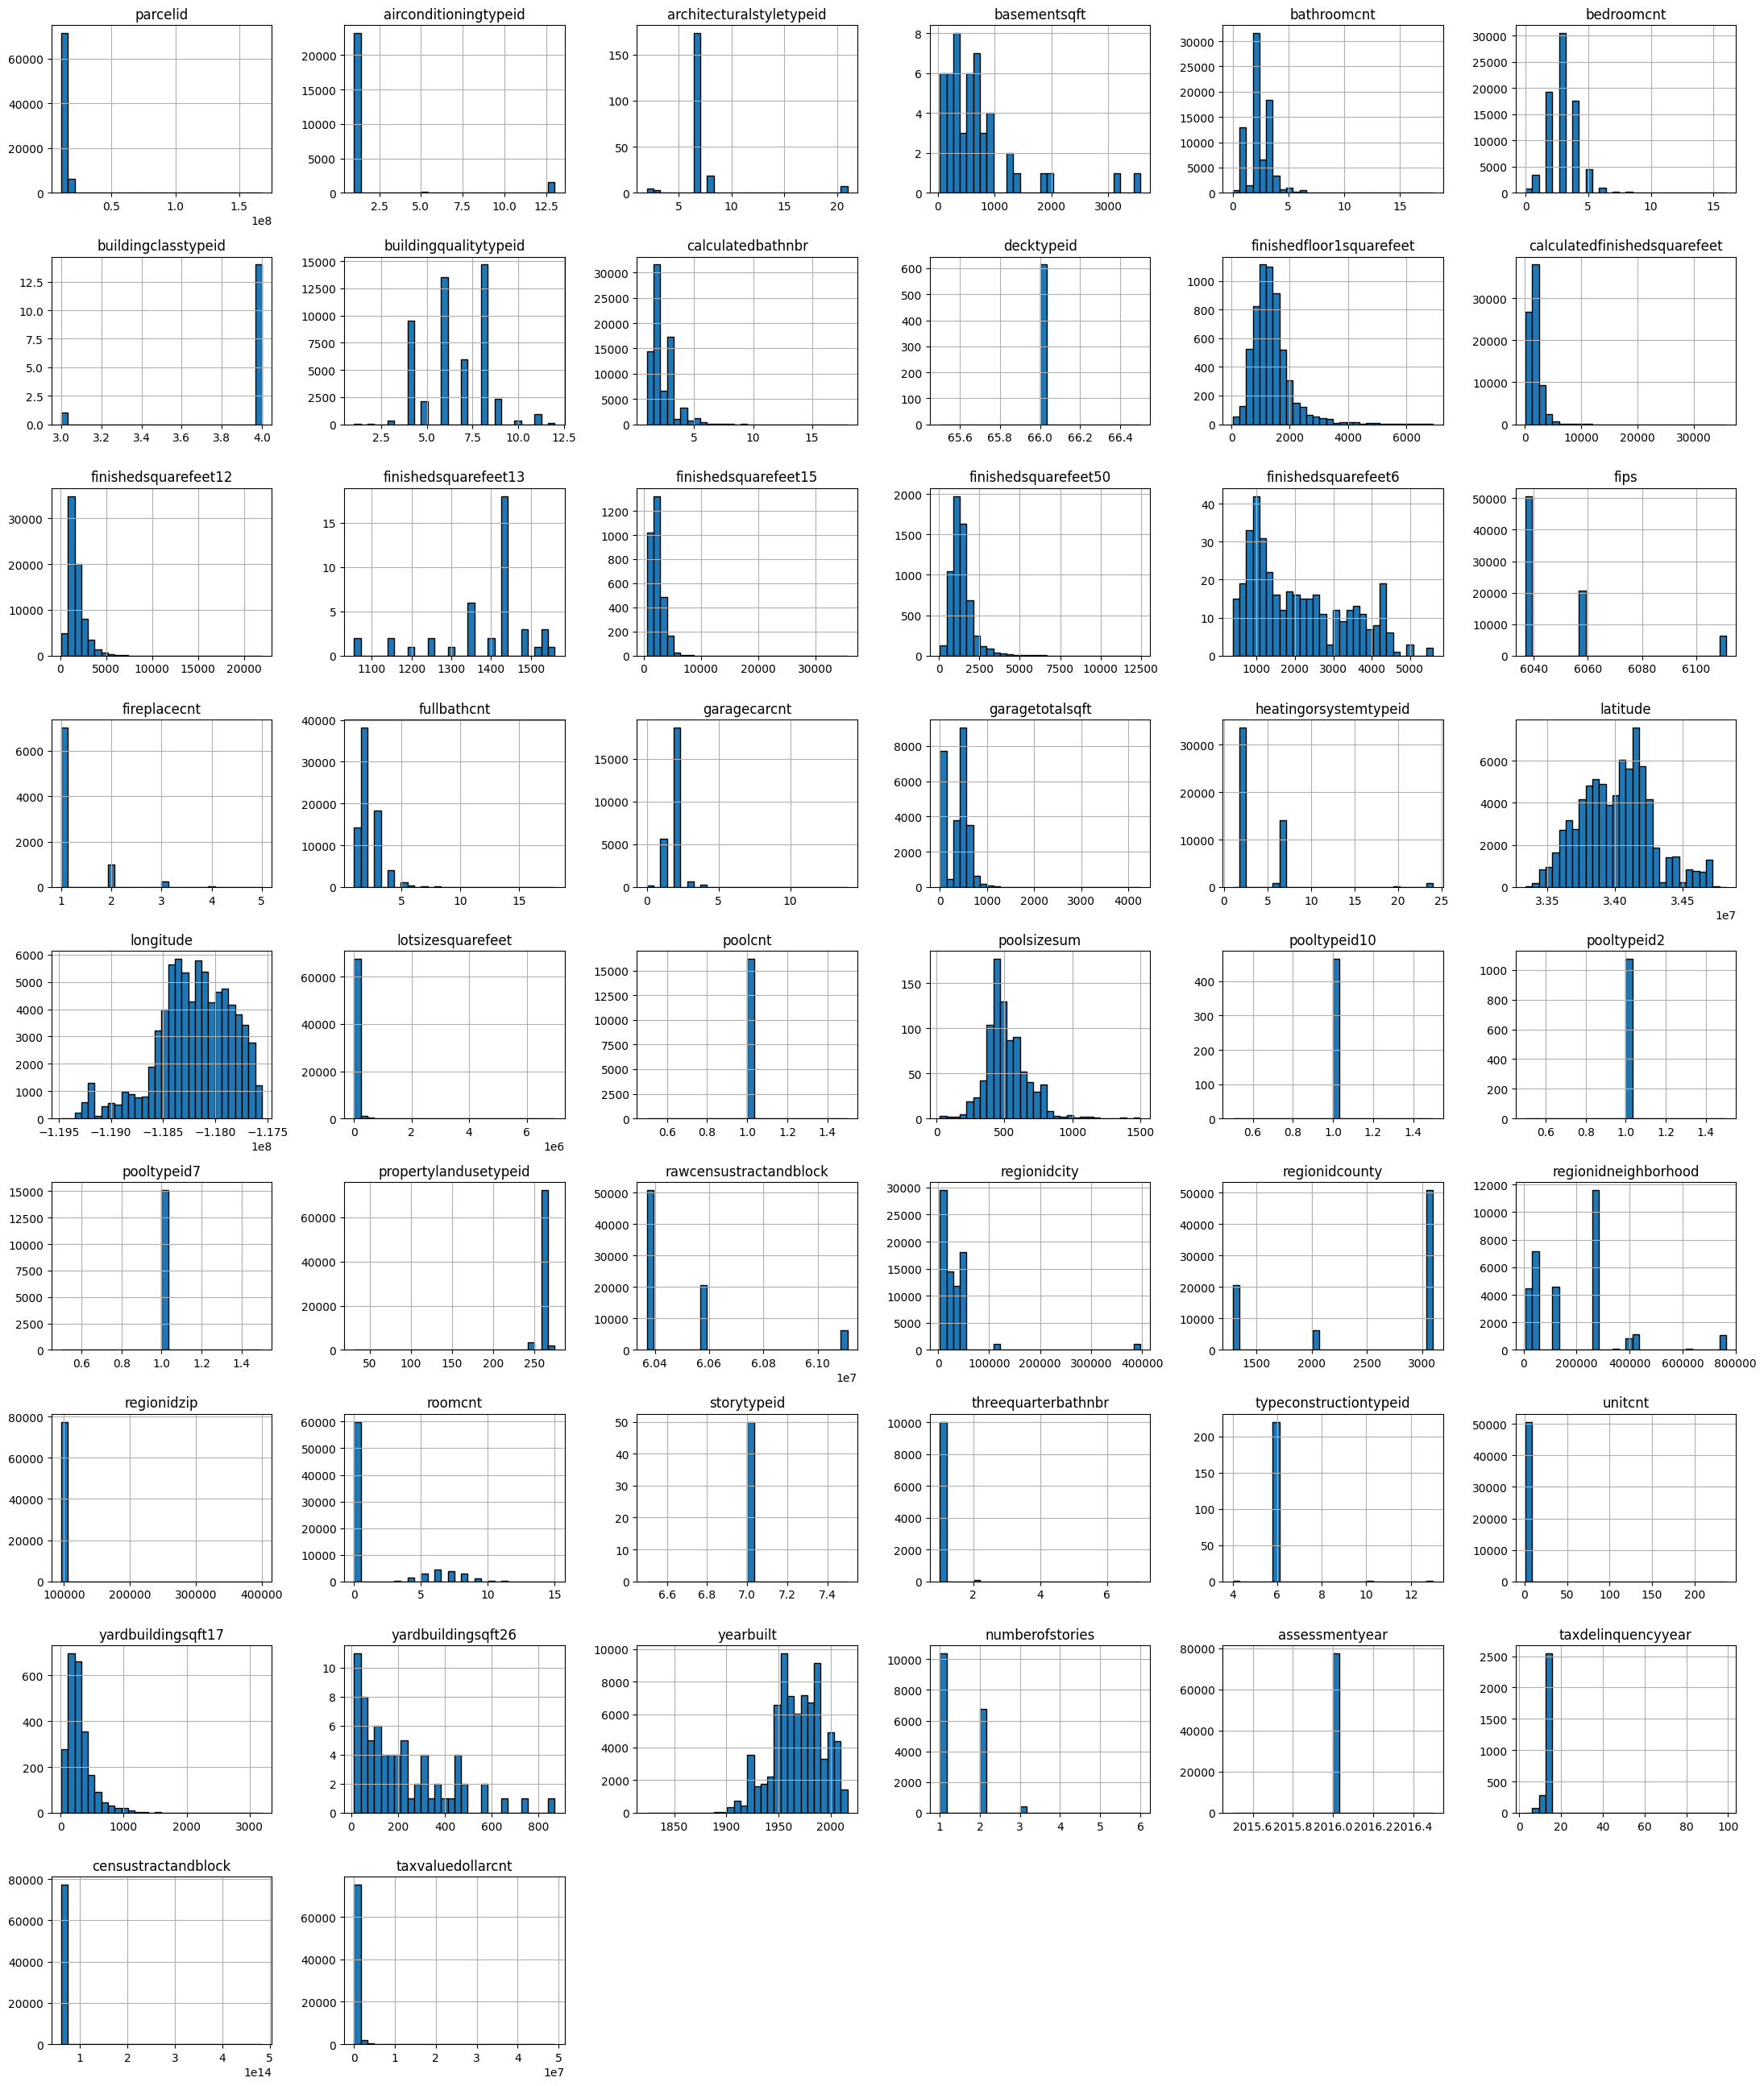

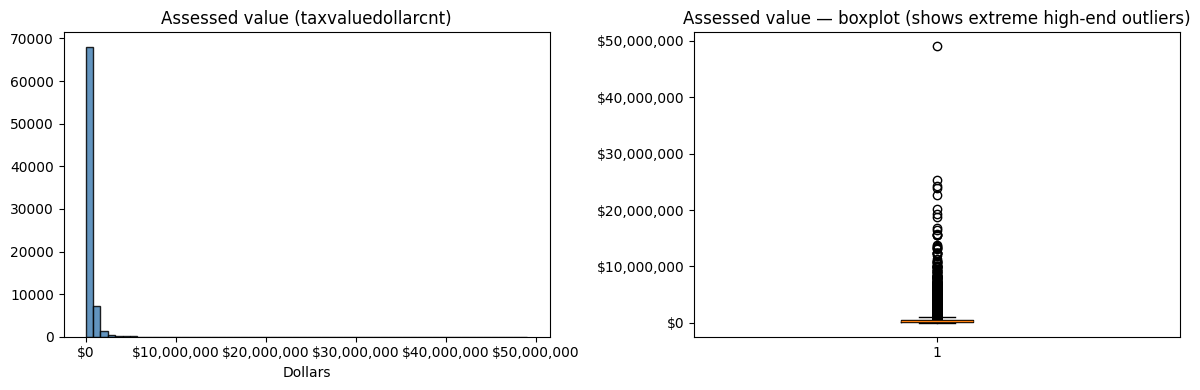

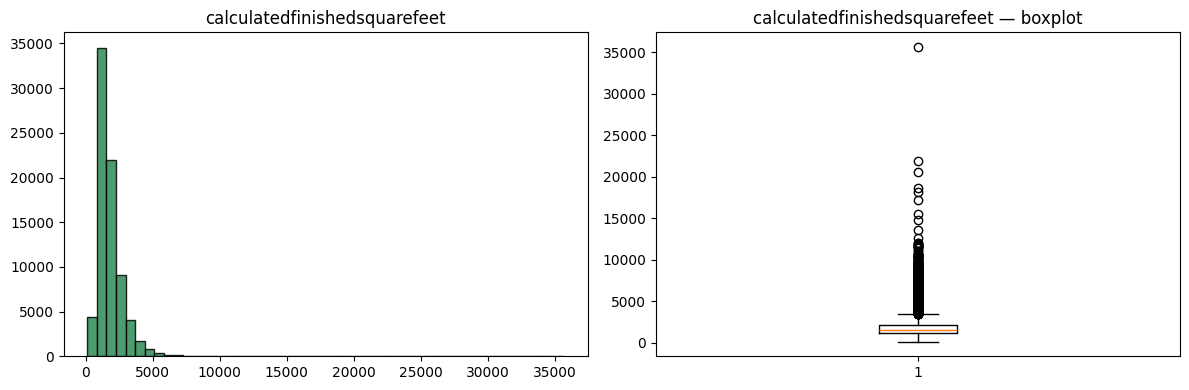

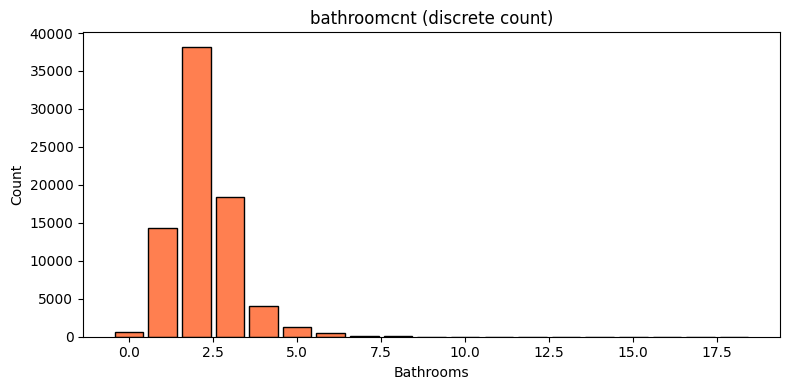

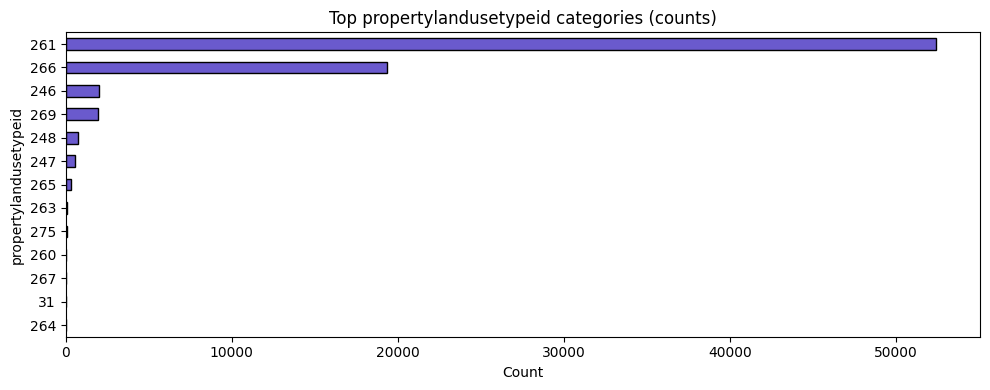

In [46]:
# --- All features: quick univariate overview ---
_ = df.hist(figsize=(22, 26), layout=(-1, 6), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

# --- Target: strongly right-skewed; very large upper tail (luxury / estates) ---
target = df["taxvaluedollarcnt"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target, bins=60, color="steelblue", edgecolor="black", alpha=0.85)
axes[0].set_title("Assessed value (taxvaluedollarcnt)")
axes[0].set_xlabel("Dollars")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[1].boxplot(target, vert=True)
axes[1].set_title("Assessed value — boxplot (shows extreme high-end outliers)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.tight_layout()
plt.show()

# --- Feature 1 (numeric): finished living area — core size driver ---
sqft = df["calculatedfinishedsquarefeet"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sqft, bins=50, color="seagreen", edgecolor="black", alpha=0.85)
axes[0].set_title("calculatedfinishedsquarefeet")
axes[1].boxplot(sqft, vert=True)
axes[1].set_title("calculatedfinishedsquarefeet — boxplot")
plt.tight_layout()
plt.show()

# --- Feature 2 (numeric): bathrooms ---
bath = df["bathroomcnt"].dropna()
plt.figure(figsize=(8, 4))
plt.hist(bath, bins=range(0, int(bath.max()) + 2), align="left", rwidth=0.85, color="coral", edgecolor="black")
plt.title("bathroomcnt (discrete count)")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# --- Feature 3 (categorical code): land use type — bar chart of counts ---
land_use = df["propertylandusetypeid"].dropna().astype(int)
vc = land_use.value_counts().head(15)
plt.figure(figsize=(10, 4))
vc.sort_values().plot(kind="barh", color="slateblue", edgecolor="black")
plt.title("Top propertylandusetypeid categories (counts)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


The target variable taxvaluedollarcnt is strongly right-skewed (closer to a log-normal distribution than a normal distribution), with a long upper tail. The boxplot shows a few very high assessed values that could dominate squared-error metrics unless we apply a transformation or use models that are robust to outliers. The feature calculatedfinishedsquarefeet is also right-skewed, with large homes pulling the distribution tail, which makes sense since living area should track property value, though not in a strictly linear way across all price ranges. The bathroomcnt variable behaves like a sparse discrete count, with many homes clustered at low integer values, meaning it likely interacts with bedrooms and square footage rather than acting as a smooth continuous variable. I also plotted propertylandusetypeid because land use is a categorical variable with a few dominant categories and a long tail of rare categories, which is useful for identifying segments that the model may need to treat separately. Overall, these plots highlight skewness, heavy tails, and categorical imbalance that should be addressed during data cleaning and modeling.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [47]:
def drop_select_cols(df, cols):
    return df.drop(columns=cols)

In [48]:
cols_to_drop = ["parcelid", 
"assessmentyear",
                
"fips",
"rawcensustractandblock",
"regionidcity",
"regionidcounty",
"regionidneighborhood",
"regionidzip",
"censustractandblock",
                
"threequarterbathnbr",
"bathroomcnt",
"calculatedbathnbr",

"finishedsquarefeet12",
"finishedsquarefeet13",

"fireplaceflag"]


df_clean_A = drop_select_cols(df, cols_to_drop)

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


The parcelid column was dropped as it acts simply as a row identifier and does not contain information regarding the property. 
Similarly, the assessmentyear column was dropped as it contains only a single value (not including nans).

The remaining columns were removed to prevent multicolinearity by removing duplicate information that is better expressed in other columns.

The columns fips, rawcensustractandblock, censustractandblock, regionidcity, regionidcounty, regionidneighborhood, and regionidzip all describe the location of the property. Thus, they have been dropped as the lattitude and longitude columns give a continous and more precise description of the property's location while containing fewer missing data.

The columns bathroomcnt and calculatedbathnbr are nearly identical with the only difference being how they encode missing data. They give the number of full and threequarter bathrooms in each property. However, this information is already calculated by the fullbathcnt and threequarterbathnbr columns while also being explicit with the number of each type. This makes the former columns redundant and thus can be removed. 

The columns finishedsquarefeet12 and finishedsquarefeet13 contain the living room area and perimeter respectively. These can be dropped in favor of keeping the calculatedfinishedsquarefeet column which also contiains the living room area with less missing values compared to finishedsquarefeet12.

The fireplaceflag column is an identifier for the presence of a fireplace in the property. This was dropped in favor of keeping the fireplacecnt column which contains the number of fireplace on the property.  

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [49]:
def drop_null_cols(df, threshold, safe_cols=[]):        
    missing_pct = df.isna().mean()

    cols_to_drop = [col for col in df.columns if (missing_pct[col] > threshold) and (col not in safe_cols)]
    
    return df.drop(columns=cols_to_drop)

In [50]:
safe_cols = ["hashottuborspa", "taxdelinquencyflag", "fireplacecnt", "threequarterbathnbr", "poolcnt"]

df_clean_B = drop_null_cols(df_clean_A, threshold=.67, safe_cols=safe_cols)

#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



All columns with a missing value percentage greater than 67% were considered for remvoval based on having too many null values. This particular threshold was chosen after observing there was a large gap of ~31% between the column with a missing value percentage of 67.8% and the column with the next highest of 36.1%. However, each column was looked at on a case by case basis, and there were few exceptions made based on the meaning of the column's null values. In particular, the columns hashottuborspa, taxdelinquencyflag, fireplacecnt, threequarterbathnbr, and poolcnt were all kept as their null values have significance. For the columns hashottuborspa and taxdelinquencyflag a null value indicates False and for the columns fireplacecnt, threequarterbathnbr, and poolcnt a null value indicates a count of 0.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [51]:
def drop_problematic_samples(df, target, null_val_threshold=None, IQR_multiplier=1.5):
    # Drop rows with null values exceeding null_val_threshold
    if null_val_threshold is None:
        null_val_threshold = len(df.columns) // 2

    nulls_per_row = df.isnull().sum(axis=1)
    df = df[nulls_per_row <= null_val_threshold]

    # Drop rows with nulls in target
    df = df.dropna(subset=[target])

    # Drop rows with outliers in target
    Q1 = df[target].quantile(0.25)
    Q3 = df[target].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR_multiplier * IQR
    upper_bound = Q3 + IQR_multiplier * IQR
    df = df[(df[target] >= lower_bound) & (df[target] <= upper_bound)]

    return df 

In [52]:
df_clean_C = drop_problematic_samples(df_clean_B, target="taxvaluedollarcnt", IQR_multiplier=5)

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


There were three criteria for whether or not a particular sample was dropped. First, if the sample had null values in at least half of the columns. Second, if there was a null value in the target column, taxvaluedollarcnt. Third, if the value in the target column was determined to be an outlier. As the target column distribution is extremely right skewed a high IQR multipler of 5 was used to determine the outliers. This helps keep some some of the multimillion dollar homes present in the cleaned dataset.  

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [53]:
def impute_missing_values(df, zero_cols, skewed_cols, mode_cols):
    # For columns that have very few missing values, simply drop the rows
    missing_pct = df.isna().mean()
    almost_complete_cols = (missing_pct[(missing_pct > 0) & (missing_pct <= 0.05)].index.tolist())
    df = df.dropna(subset=almost_complete_cols).copy()

    # For columns where nulls already have a meaning, assign them to 0
    for col in zero_cols:
        df[col] = df[col].fillna(0)
    
    # For numerical columns that are skewed, fill with median
    for col in skewed_cols:
        df[col] = df[col].fillna(df[col].median())

    # For remaining categorical columns, fill with most common value
    for col in mode_cols:
        df[col] = df[col].fillna(df[col].mode().iloc[0])
    
    return df
    

In [54]:
zero_cols = ["hashottuborspa", "taxdelinquencyflag", "fireplacecnt", "poolcnt", "heatingorsystemtypeid"]
skewed_cols = ["lotsizesquarefeet", "unitcnt"]
mode_cols = ["buildingqualitytypeid", "propertyzoningdesc"]


df_clean_D = impute_missing_values(df_clean_C, zero_cols=zero_cols, skewed_cols=skewed_cols, mode_cols=mode_cols)

#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


The columns fullbathcnt, yearbuilt, and calculatedfinishedsquarefeet had such low missing value percentages (<0.6%) that the rows where they had missing values were dropped instead of imputed. 

As previously discussed null values for the columns hashottuborspa, taxdelinquencyflag, fireplacecnt, and poolcnt correspond to the absence the feature, and therefore, their null values were imputed as 0. Additionally, a null value in  heatingorsystemtypeid corresponds to the property not having heating and was similarly imputed as 0. 

The columns lotsizesquarefeet and unitcnt are both numerical columns with skewed distributions. Thus, they were imputed using their median values. 

The columns buildingqualitytypeid and propertyzoningdesc are both categorical columns with no particular meaning to their null values. Thus, they were imputed using their most frequent value. 

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [55]:
def encode_cols(df, cols_to_encode):
    ordinal = OrdinalEncoder()
    df[cols_to_encode] = ordinal.fit_transform(df[cols_to_encode])
    return df

In [56]:
df_clean_D["hashottuborspa"] = df_clean_D["hashottuborspa"].replace(True, 1)

df_clean_D["taxdelinquencyflag"] = df_clean_D["taxdelinquencyflag"].replace("Y", 1)

cols_to_encode = ["propertycountylandusecode", "propertyzoningdesc"]

df_clean = encode_cols(df_clean_D, cols_to_encode)

C:\Users\mayas\AppData\Local\Temp\ipykernel_22928\3878798632.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean_D["hashottuborspa"] = df_clean_D["hashottuborspa"].replace(True, 1)
C:\Users\mayas\AppData\Local\Temp\ipykernel_22928\3878798632.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean_D["taxdelinquencyflag"] = df_clean_D["taxdelinquencyflag"].replace("Y", 1)


In [57]:
feature_overview = pd.DataFrame(
    {
        "dtype": df_clean.dtypes.astype(str),
        "missing_pct": (df_clean.isna().mean() * 100).round(2),
        "nunique": df_clean.nunique(),
    }
)

feature_overview["usefulness_note"] = np.where(
    feature_overview.index == "taxvaluedollarcnt",
    "Regression target",
    "",
)
display(feature_overview.sort_values("missing_pct", ascending=False))

,dtype,missing_pct,nunique,usefulness_note
bedroomcnt,float64,0.0,15,
buildingqualitytypeid,float64,0.0,12,
calculatedfinishedsquarefeet,float64,0.0,4552,
fireplacecnt,float64,0.0,6,
fullbathcnt,float64,0.0,10,
hashottuborspa,int64,0.0,2,
heatingorsystemtypeid,float64,0.0,11,
latitude,float64,0.0,62525,
longitude,float64,0.0,60914,
lotsizesquarefeet,float64,0.0,18301,


The column hashottuborspa contained only the unique values of 0 and True. Thus, True was simply encoded as 1. Similarly, the column taxdelinquencyflag contained 0 and Y,  so Y was also encoded as 1. The columns propertylandusetypeid and propertyzoningdesc were encoded using ordinal encoding. 

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

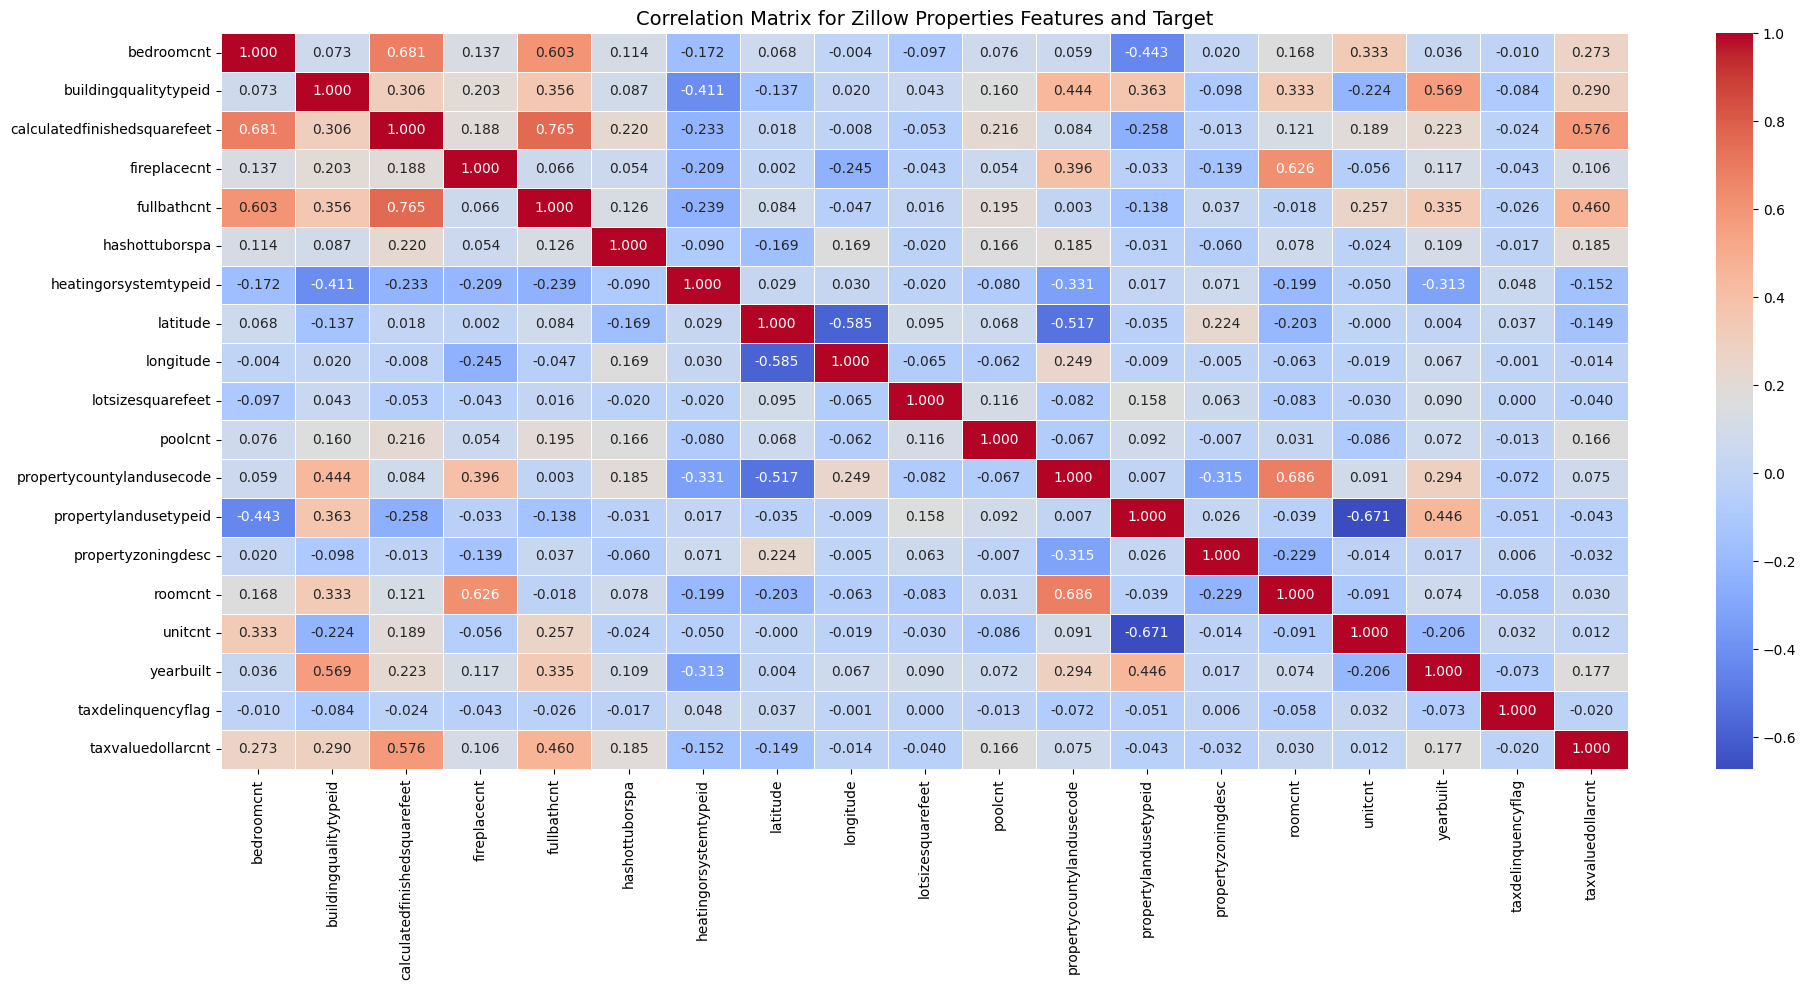

In [58]:
#Generating a correlation matrix
corr_matrix = df_clean.corr()

#Plotting the correlation matrix as a heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", cbar=True, fmt=".3f",
            linewidths=0.5, xticklabels=corr_matrix.columns, yticklabels=corr_matrix.index)

# Adding a title and ensuring the figure shows correctly
plt.title("Correlation Matrix for Zillow Properties Features and Target", fontsize=14)
plt.tight_layout()
plt.show()

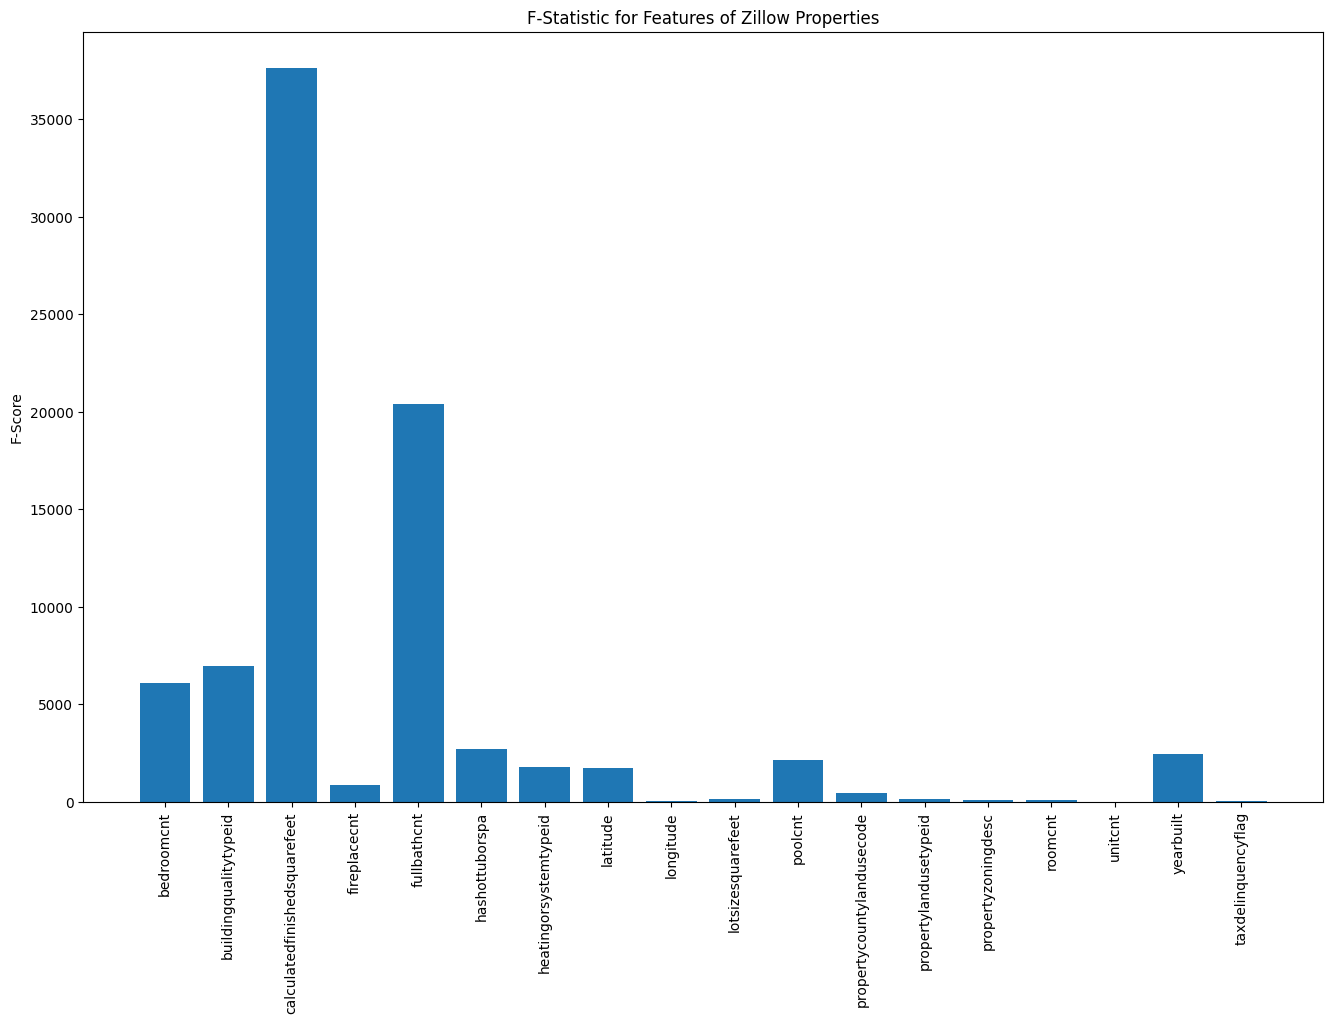

In [59]:
#Separating features from target
y = df_clean['taxvaluedollarcnt']              
X = df_clean.drop(columns=['taxvaluedollarcnt'])  

#Scaling the features and response for proper F-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).flatten() 

#Calculating the f-statistic
f_scores, p_values = f_regression(X_scaled, y_scaled)

#Generating the f-statistic matrix
f_score_matrix = pd.DataFrame(f_scores.reshape(1, -1), columns=X.columns, index=["F-Score"])

#Plotting results in a bar chart
plt.figure(figsize=(16,10))
plt.bar(X.columns, f_scores)
plt.ylabel("F-Score")
plt.xticks(rotation=90) 
plt.title("F-Statistic for Features of Zillow Properties")
plt.show()

The following features appear to have significant correlation with the target: 'calculatedfinishedsquarefeet', 'fullbathcnt', 'buildingqualitytypeid', and 'bedroomcnt'.

In [60]:
#Creating forward feature selection function
def forward_feature_selection(X, y, model, 
                                      scoring='neg_mean_squared_error', 
                                      cv=5, 
                                      tol=None,                                                       
                                      max_features=None,      
                                      n_jobs = -1,
                                      verbose = True
                                     ):
    selected_features = []
    remaining_features = list(X.columns)
    best_scores = []
    previous_score = float('inf')
    
    # Model to use for evaluation
    model = LinearRegression()

    # Track the best subset and its score
    best_forward_features = None
    best_score = float('inf')
    
    while remaining_features:
        scores = {}
        for feature in remaining_features:
            current_features = selected_features + [feature]
            # Compute the CV score
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring=scoring, cv=cv,n_jobs=n_jobs,
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant
        if verbose and tol is not None and previous_score - current_score < tol:
            print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"Features: {selected_features}, CV Score (MSE): {current_score:.4f}")
        
        # Update the best subset if the current score is the best so far
        if current_score < best_score:
            best_score = current_score
            best_forward_features = selected_features.copy()
        
        # Check if max_features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return selected_features, best_scores, best_forward_features, best_score

Features: ['calculatedfinishedsquarefeet'], CV Score (MSE): 82811420008.8687
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt'], CV Score (MSE): 79453279742.2118
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude'], CV Score (MSE): 76783280534.6630
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude'], CV Score (MSE): 75026734660.5437
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude', 'roomcnt'], CV Score (MSE): 74087161384.8377
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude', 'roomcnt', 'buildingqualitytypeid'], CV Score (MSE): 73000864983.5475
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude', 'roomcnt', 'buildingqualitytypeid', 'unitcnt'], CV Score (MSE): 72553094586.3095
Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude', 'roomcnt', 'buildingqualitytypeid', 'unitcnt', 'fullbathcnt'], CV Score (MSE): 7235517789

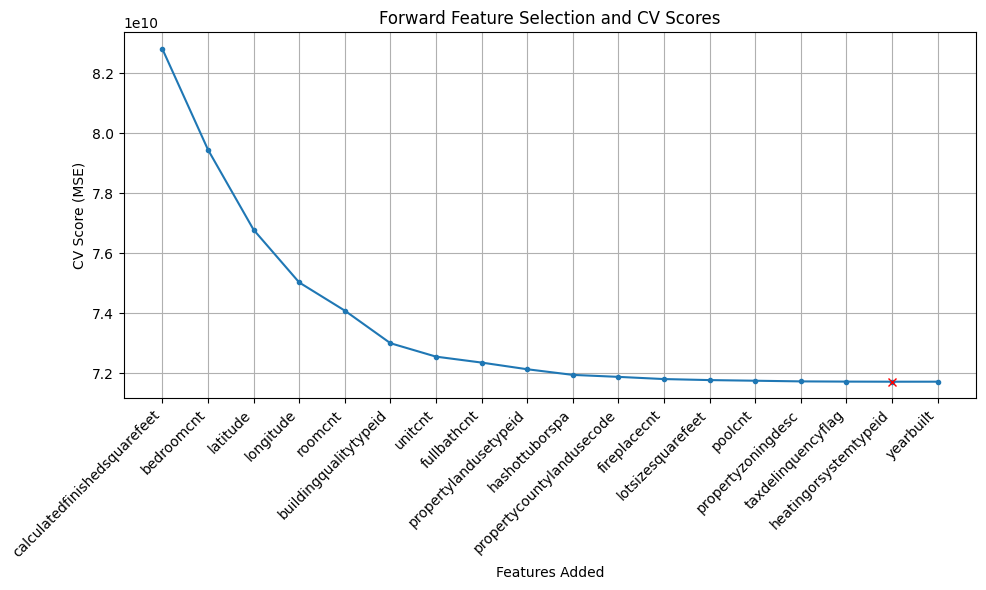

Best Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'latitude', 'longitude', 'roomcnt', 'buildingqualitytypeid', 'unitcnt', 'fullbathcnt', 'propertylandusetypeid', 'hashottuborspa', 'propertycountylandusecode', 'fireplacecnt', 'lotsizesquarefeet', 'poolcnt', 'propertyzoningdesc', 'taxdelinquencyflag', 'heatingorsystemtypeid']
Best CV Score: 71717465607.9246
Test MSE: 72176148477.5031


In [61]:
# Running forward feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state)

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train, y_train, model, verbose=True) )

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1],best_score,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=45, ha='right')
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (MSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_score:.4f}")

# Testing

# Filter X_train and X_test to include only the selected features
X_train_best = X_train[best_forward_features]
X_test_best = X_test[best_forward_features]

# Run the test set through the model
model = LinearRegression()
model.fit(X_train_best, y_train)

y_pred = model.predict(X_test_best)

test_mse = mean_squared_error(y_test, y_pred)

print(f"Test MSE: {test_mse:.4f}")

In [62]:
#Creating backward feature selection function

def backward_feature_selection(X, y, model, 
                               scoring='neg_mean_squared_error', 
                               cv=5, 
                               tol=None,                                    
                               max_features=None,
                               n_jobs=-1,
                               verbose=True
                              ):
    
    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y, 
                                scoring=scoring, cv=cv, 
                                n_jobs=n_jobs          ).mean()
    
    # Start with all features (using a list for easier manipulation)
    features_remaining_b = list(X.columns)
    
    # Compute initial CV score with the full feature set
    initial_score_b = cv_score(features_remaining_b)
    
    # Initialize tracking variables
    best_score_b        = initial_score_b                # Best (lowest) CV score observed so far
    best_feature_set_b  = features_remaining_b.copy()    # Feature set corresponding to best_score
    selected_features_b = ['NONE']                     # List to record the order in which features are removed
    best_scores_b       = [initial_score_b]              # List to record the CV score after each removal (starting with full set)
    
    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining_b}  CV score (MSE): {np.around(initial_score_b, 4)}\n')
    
    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count_b = 1 if max_features is None else max_features
    
    prev_score_b = initial_score_b
    round_num_b = 1
    # Continue removing features until we reach the target count
    while len(features_remaining_b) > target_feature_count_b:
        if verbose:
            print(f'Round {round_num_b}:')
            
        # Initialize variables to track the best removal in this round
        lowest_score_b = float('inf')
        feature_to_remove_b = None
        best_new_features_b = None
        
        # Try removing each feature one at a time
        for feature_b in features_remaining_b:
            new_feature_set_b = features_remaining_b.copy()
            new_feature_set_b.remove(feature_b)
            new_score_b = cv_score(new_feature_set_b)
            if verbose:
                print('Trying removal of:',feature_b, np.around(new_score_b, 4))
            if new_score_b < lowest_score_b:
                lowest_score_b = new_score_b
                feature_to_remove_b = feature_b
                best_new_features_b = new_feature_set_b
        
        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score_b - lowest_score_b) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break
        
        # Update the best score and feature set if current removal improves performance
        if lowest_score_b < best_score_b:
            best_score_b = lowest_score_b
            best_feature_set_b = best_new_features_b.copy()
        
        # Update trackers for this round
        prev_score_b = lowest_score_b
        features_remaining_b = best_new_features_b
        selected_features_b.append(feature_to_remove_b)
        best_scores_b.append(lowest_score_b)
        
        if verbose:
            print(f'\nRemoving {feature_to_remove_b}:  CV score (MSE) {np.around(lowest_score_b, 4)}\n')
        round_num_b += 1

    return (
        selected_features_b,      # Order in which features were removed
        best_scores_b,            # CV scores after each removal step
        best_feature_set_b,       # Feature set that achieved the best CV score
        best_score_b              # Best (lowest) CV score
    )

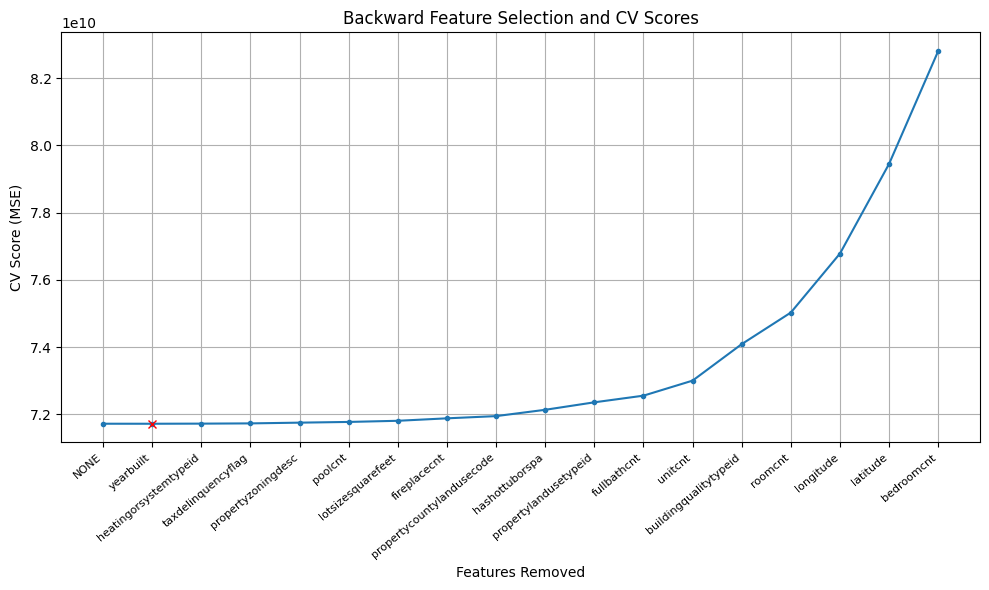

Best feature set: ['bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'fireplacecnt', 'fullbathcnt', 'hashottuborspa', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'roomcnt', 'unitcnt', 'taxdelinquencyflag']
CV score (MSE): 71717465607.9255
Test MSE: 72176148477.5060


In [63]:
#Running backward selection and displaying results

model_b = LinearRegression()

selected_features_b, best_scores_b, best_feature_set_b, best_score_b = (
    backward_feature_selection(X_train, y_train, model_b, verbose=False)                             
)

plt.figure(figsize=(10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores_b) + 1), best_scores_b, marker='.')
index_b = np.argmin(best_scores_b) 
plt.plot([index_b + 1], best_scores_b[index_b], marker='x', color='red')  
plt.xticks(range(1, len(selected_features_b) + 1), selected_features_b, rotation=40, ha='right', fontsize=8)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print minimum cv score

print("Best feature set:", best_feature_set_b)
print("CV score (MSE):",np.around(best_score_b,4))


# Test

# Filter X_train and X_test to include only the selected features
X_train_best_backward = X_train[best_feature_set_b]
X_test_best_backward = X_test[best_feature_set_b]

# Train the LinearRegression model on the selected features
model_b = LinearRegression()
model_b.fit(X_train_best_backward, y_train)

# Predict on the test set
y_pred_b = model_b.predict(X_test_best_backward)

# Calculate the test MSE
test_mse_b = mean_squared_error(y_test, y_pred_b)

print(f"Test MSE: {test_mse_b:.4f}")

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



According to the correlation matrix and f-scores, the following features appear to be strongly positively correlated with the target variable: 'calculatedfinishedsquarefeet', 'fullbathcnt', 'buildingqualitytypeid', and 'bedroomcnt'. Each of these features have strong correlations with other features as well. Firstly, 'calculatedfinishedsquarefeet' appears to be positively correlated with 'fullbathcnt', 'buildingqualitytypeid', and 'bedroomcnt' as well, in addition to 'hashottuborspa', 'poolcnt', and 'yearbuilt'. There is also negative correlation with 'heatingorsystemtypeid' and 'propertylandusetypeid'. Next, 'fullbathcnt' is also positively correlated with 'bedroomcnt', 'buildingqualitytypeid', and 'calculatedfinishedsquarefeet' as well as 'unitcnt' and 'yearbuilt'. It is negatively correlated with 'heatingorsystemtypeid'. Then, 'buildingqualitytypeid' is positively correlated with 'calculatedfinishedsquarefeet' and 'fullbathcnt' as well as 'fireplacecnt', 'propertycountylandusecode', 'propertylandusetypeid', 'roomcnt', and 'yearbuilt'. It is negatively correlated with 'heatingorsystemtypeid' and 'unitcnt'. Finally, 'bedroomcnt' is positively correlated with 'calculatedfinishedsquarefeet', 'fullbathcnt', and 'unitcnt'. It is negatively correlated with 'propertylandusetypeid'. Forward and backward feature selections showed that the best subset of features is ['bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'fireplacecnt', 'fullbathcnt', 'hashottuborspa', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'roomcnt', 'unitcnt', 'taxdelinquencyflag']. The correlation matrix and f-scores agree, and the forward and backward feature selections agree. The feature selections include features not deemed significant in the correlation matrix and f-score: 'fireplacecnt', 'latitude', 'longitude', 'lotsizesquarefeet', 'propertyzoningdesc', and 'taxdelinquencyflag'.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

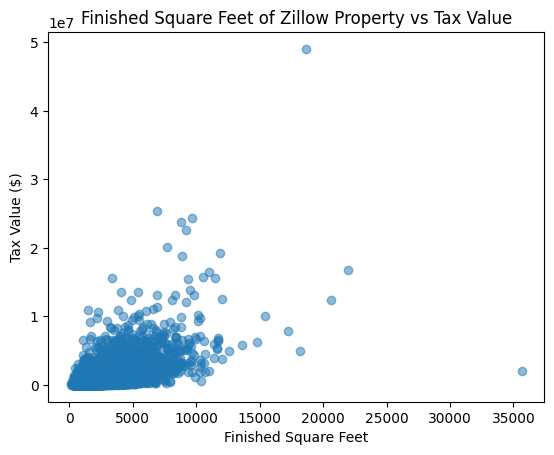

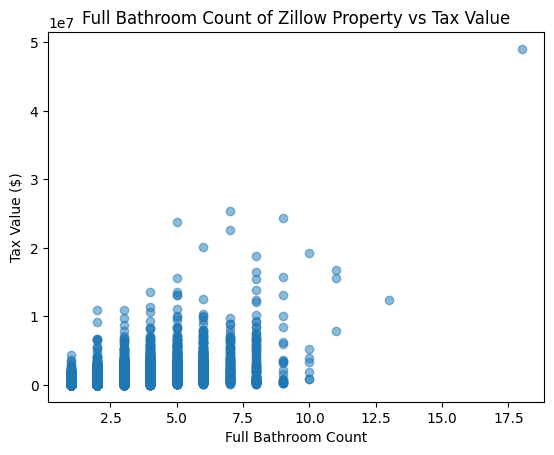

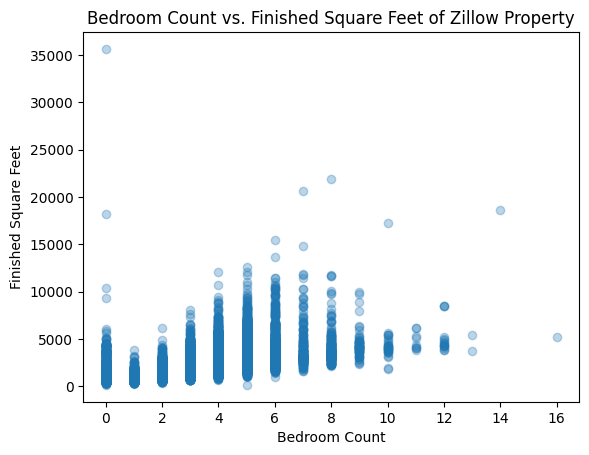

In [64]:
#Pair 1: 'calculatedfinishedsquarefeet' and 'taxvaluedollarcnt'
plt.scatter(df['calculatedfinishedsquarefeet'], df['taxvaluedollarcnt'], alpha=0.5)
plt.xlabel('Finished Square Feet')
plt.ylabel('Tax Value ($)')
plt.title('Finished Square Feet of Zillow Property vs Tax Value')
plt.show()

#Pair 2: 'fullbathcnt' and 'taxvaluedollarcnt'
plt.scatter(df['fullbathcnt'], df['taxvaluedollarcnt'], alpha=0.5)
plt.xlabel('Full Bathroom Count')
plt.ylabel('Tax Value ($)')
plt.title('Full Bathroom Count of Zillow Property vs Tax Value')
plt.show()

#Pair 2: 'calculatedfinishedsquarefeet' and 'bedroomcnt'
plt.scatter(df['bedroomcnt'], df['calculatedfinishedsquarefeet'], alpha=0.3)
plt.xlabel('Bedroom Count')
plt.ylabel('Finished Square Feet')
plt.title('Bedroom Count vs. Finished Square Feet of Zillow Property')
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The first plot suggests that as the finished square feet of a property increases, as does the tax value. This is expected, as greater usable space (living areas, bedrooms, bathrooms, etc) increases property value, which intuitively means greater tax value.  
  
The second plot suggests that as the full bathroom count of a property increases, as does the tax value. This is also expected, as a greater number of bathrooms indicates more usable space, which increases property value. As above, this leads to greater tax value.  
  
The third plot is more complex to interpret. Excluding outliers, it appears that up to a certain number of bedrooms (around 7, namely), finished square feet and bedroom count tend to increase together. After 7 bedrooms, finished square footage tends to decrease with increasing bedroom count. This pattern may exist for a few reasons. First, there are a lot less properties with more than 7 bedrooms, so there is less data to explore. Second, properties with more than 7 bedrooms may not be typical single homes; instead, they can be apartment buildings or multi-use properties. These do not necessarily have more square footage than single homes, opting for a greater number of bedrooms in an smaller space. 

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [65]:
#Log transformation of 'calculatedfinishedsquarefeet', adding a new column to the dataset
df_clean['log_calculatedfinishedsquarefeet'] = np.log(df_clean['calculatedfinishedsquarefeet'])
df_clean.head()

,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,roomcnt,unitcnt,yearbuilt,taxdelinquencyflag,taxvaluedollarcnt,log_calculatedfinishedsquarefeet
0,4.0,8.0,3100.0,0.0,3.0,0,0.0,33634931.0,-117869207.0,4506.0,0.0,51.0,261.0,570.0,0.0,1.0,1998.0,0,1023282.0,8.039157
1,2.0,8.0,1465.0,1.0,1.0,0,0.0,34449266.0,-119281531.0,12647.0,0.0,43.0,261.0,570.0,5.0,1.0,1967.0,0,464000.0,7.289611
2,3.0,8.0,1243.0,0.0,2.0,0,0.0,33886168.0,-117823170.0,8432.0,1.0,51.0,261.0,570.0,6.0,1.0,1962.0,0,564778.0,7.125283
3,4.0,8.0,2376.0,0.0,3.0,0,2.0,34245180.0,-118240722.0,13038.0,1.0,1.0,261.0,782.0,0.0,1.0,1970.0,0,145143.0,7.773174
4,3.0,8.0,1312.0,0.0,3.0,0,2.0,34185120.0,-118414640.0,278581.0,1.0,8.0,266.0,577.0,0.0,1.0,1964.0,0,119407.0,7.179308


In [66]:
#Calculating and comparing the correlation between 'calculatedfinishedsquarefeet' before and after log transformation with the target
corr_orig_sqft = df_clean['calculatedfinishedsquarefeet'].corr(df_clean['taxvaluedollarcnt'])
corr_log_sqft = df_clean['log_calculatedfinishedsquarefeet'].corr(df_clean['taxvaluedollarcnt'])
print('Correlation between calculatedfinishedsquarefeet and target:', corr_orig_sqft)
print('Correlation between log_calculatedfinishedsquarefeet and target:', corr_log_sqft)

Correlation between calculatedfinishedsquarefeet and target: 0.575726545244859
Correlation between log_calculatedfinishedsquarefeet and target: 0.5347721443462091


In [67]:
# Log transformation of target column, 'taxvaluedollarcnt'
df_clean['log_taxvaluedollarcnt'] = np.log(df_clean['taxvaluedollarcnt'])
df_clean.head()

,bedroomcnt,buildingqualitytypeid,calculatedfinishedsquarefeet,fireplacecnt,fullbathcnt,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,roomcnt,unitcnt,yearbuilt,taxdelinquencyflag,taxvaluedollarcnt,log_calculatedfinishedsquarefeet,log_taxvaluedollarcnt
0,4.0,8.0,3100.0,0.0,3.0,0,0.0,33634931.0,-117869207.0,4506.0,0.0,51.0,261.0,570.0,0.0,1.0,1998.0,0,1023282.0,8.039157,13.838526
1,2.0,8.0,1465.0,1.0,1.0,0,0.0,34449266.0,-119281531.0,12647.0,0.0,43.0,261.0,570.0,5.0,1.0,1967.0,0,464000.0,7.289611,13.047640
2,3.0,8.0,1243.0,0.0,2.0,0,0.0,33886168.0,-117823170.0,8432.0,1.0,51.0,261.0,570.0,6.0,1.0,1962.0,0,564778.0,7.125283,13.244188
3,4.0,8.0,2376.0,0.0,3.0,0,2.0,34245180.0,-118240722.0,13038.0,1.0,1.0,261.0,782.0,0.0,1.0,1970.0,0,145143.0,7.773174,11.885475
4,3.0,8.0,1312.0,0.0,3.0,0,2.0,34185120.0,-118414640.0,278581.0,1.0,8.0,266.0,577.0,0.0,1.0,1964.0,0,119407.0,7.179308,11.690293


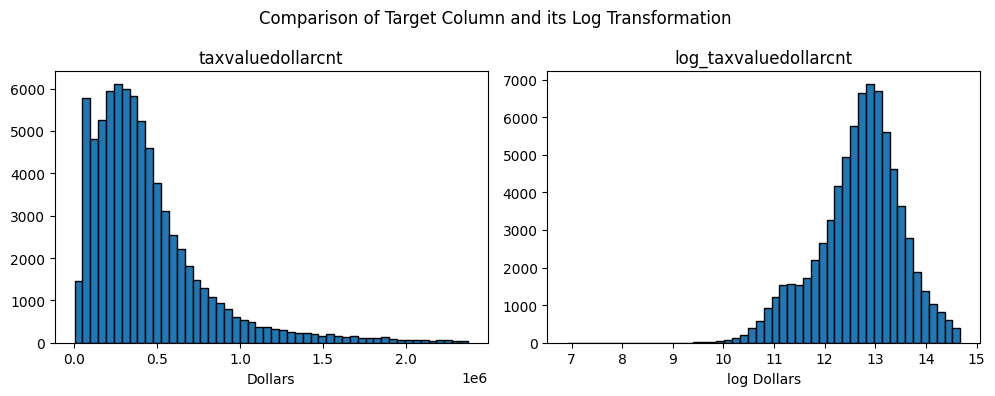

In [ ]:
# Plotting taxvaluedollarcnt and log_taxvaluedollarcnt for comparison in distribution 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df_clean['taxvaluedollarcnt'], bins=50, edgecolor='black')
axes[0].set_title('taxvaluedollarcnt')
axes[0].set_xlabel("Dollars")

axes[1].hist(df_clean['log_taxvaluedollarcnt'], bins=50, edgecolor='black')
axes[1].set_title('log_taxvaluedollarcnt')
axes[1].set_xlabel("log Dollars")

fig.suptitle('Comparison of Target Column and its Log Transformation')
plt.tight_layout()
plt.show()

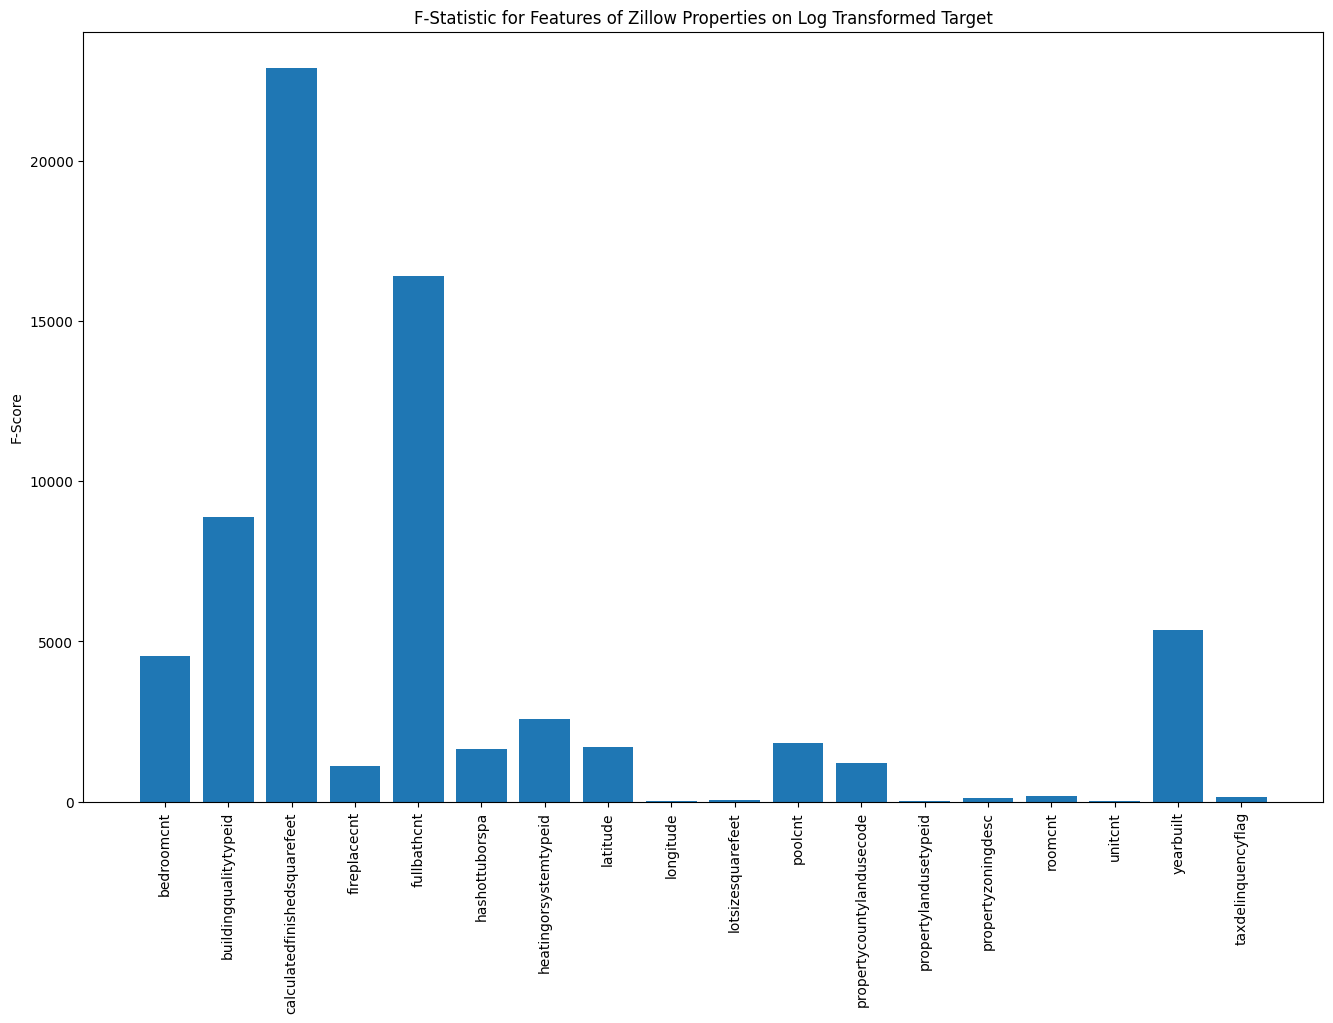

In [ ]:
# Calculating f-statistic as in part 4, but using log_taxvaluedollarcnt as new target
y = df_clean['log_taxvaluedollarcnt']              
X = df_clean.drop(columns=['taxvaluedollarcnt', 'log_taxvaluedollarcnt', 'log_calculatedfinishedsquarefeet'])  

#Scaling the features and response for proper F-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).flatten() 

#Calculating the f-statistic
f_scores, p_values = f_regression(X_scaled, y_scaled)

#Generating the f-statistic matrix
f_score_matrix = pd.DataFrame(f_scores.reshape(1, -1), columns=X.columns, index=["F-Score"])

#Plotting results in a bar chart
plt.figure(figsize=(16,10))
plt.bar(X.columns, f_scores)
plt.ylabel("F-Score")
plt.xticks(rotation=90) 
plt.title("F-Statistic for Features of Zillow Properties on Log Transformed Target")
plt.show()

Features: ['calculatedfinishedsquarefeet'], CV Score (MSE): 0.5188
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid'], CV Score (MSE): 0.4959
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude'], CV Score (MSE): 0.4841
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude'], CV Score (MSE): 0.4755
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude', 'roomcnt'], CV Score (MSE): 0.4655
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude', 'roomcnt', 'yearbuilt'], CV Score (MSE): 0.4607
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude', 'roomcnt', 'yearbuilt', 'bedroomcnt'], CV Score (MSE): 0.4590
Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude', 'roomcnt', 'yearbuilt', 'bedroomcnt', 'fullbathcnt'], CV Score (MSE): 0.4577
Features: ['calculatedfini

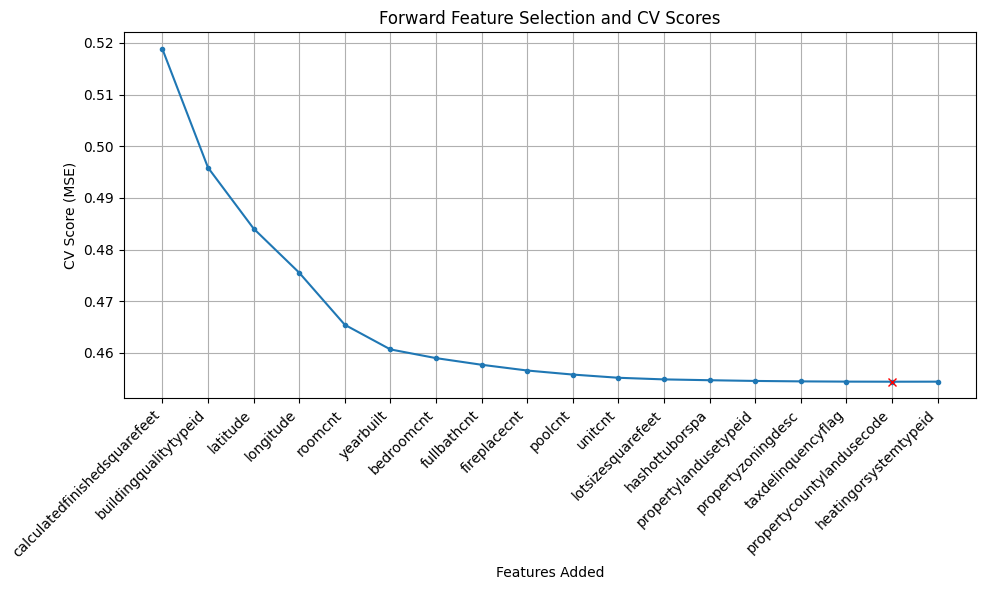

Best Features: ['calculatedfinishedsquarefeet', 'buildingqualitytypeid', 'latitude', 'longitude', 'roomcnt', 'yearbuilt', 'bedroomcnt', 'fullbathcnt', 'fireplacecnt', 'poolcnt', 'unitcnt', 'lotsizesquarefeet', 'hashottuborspa', 'propertylandusetypeid', 'propertyzoningdesc', 'taxdelinquencyflag', 'propertycountylandusecode']


In [83]:
# Running forward feature selection as in part 4, but using log_taxvaluedollarcnt as new target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state)

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_score =    (
            forward_feature_selection(X_train, y_train, model, verbose=True) )

# Plot the results
index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1],best_score,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=45, ha='right')
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (MSE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


We chose to log transform the 'calculatedfinishedsquarefeet' column because visualization with a histogram and a boxplot demonstrated a highly right-skewed distribution. We believed that this transformation could improve readability of these visualizations and might also improve future model performance. However, we observed that the correlation between 'calculatedfinishedsquarefeet' and the target variable is greater than the correlation between 'log_calculatedfinishedsquarefeet' and the target variable, indicating that the log transformation weakened the relationship between finished square feet of a property and its assessed tax value. Thus, while the distribution improved, its predictive value decreased.

There was second log transformation done on the target column, 'taxvaluedollarcnt', due to the heavy right-skewness of its distribution. By plotting the histograms of 'taxvaluedollarcnt' and the transformed 'log_taxvaluedollarcnt', it can be visually confirmed that the orginal right-skew is shifted to be a roughly normal distribution as expected. Interestingly, the f-statistic expereinces a sort of 'compression' when it is calculated using the new 'log_taxvaluedollarcnt'. The features with the largest f-statistic, 'calculatedfinishedsquarefeet' and 'fullbathcnt', still remain the top two; however, the ratio between their f-statistic and the other features' f-statistic becomes much smaller. This suggests that a model built using the 'log_taxvaluedollarcnt' would not weigh these features as highly than a model built using 'taxvaluedollarcnt'. Further, when performing forward feature selection 'yearbuilt' is now included in the subset of best features while 'heatingsystemtypeid' is now excluded. The order of features selected has also changed with 'buildingqualitytypeid' being selected sooner and 'bedroomcnt' and 'unitcnt' being selected later. The results from the f-statistic caclulation and forward feature selection are not surprising, as when the log transformation is applied, the extremely large data points, corresponding to the multimillion dollar properties, are no longer considered extreme outliers. This lowers the influence of the luxury properties and conversely increasing the influence of the lower valued properties on these calculations. Thus, a using 'log_taxvaluedollarcnt' instead of the original take would cause a model weigh the features of all properties more equally, rather than being hyperfocused on what features are overrepresented in the luxury properties.  

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

